# Phase 3 — Transfer Learning

**Learning Goals**
- Load and adapt a pretrained CNN (VGG16, ResNet50, or MobileNetV2)
- Freeze the base and train a custom classification head
- Fine-tune the top layers of the base model
- Compare transfer learning performance vs the baseline MLP

**Tasks to complete:**
1. `TODO 6` in `src/models.py` — `build_transfer_model()`
2. `TODO 7` in `src/models.py` — `unfreeze_top_layers()`

Run `pytest tests/test_phase3.py -v` to check your work.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_data_generators, compute_class_weights
from src.train import get_callbacks, train_model, plot_history
from src.evaluate import evaluate_model

In [2]:
# Use full 224x224 resolution for pretrained models
train_gen, val_gen, test_gen = get_data_generators(
    data_dir='../data/chest_xray',
    img_size=(224, 224),
    batch_size=32,
)
class_weights = compute_class_weights(train_gen)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Step 1 — Feature Extraction (Frozen Base)

Implement `build_transfer_model()` in `src/models.py`, then run the cells below.

In [3]:
from src.models import build_transfer_model

model = build_transfer_model(
    base_model_name='MobileNetV2',
    input_shape=(224, 224, 3),
    dropout_rate=0.3,
    learning_rate=1e-3,
    freeze_base=True,
)
model.summary()

# Count trainable vs non-trainable params
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'Trainable params: {trainable:,}  |  Frozen params: {frozen:,}')

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                             

Epoch 1/15
163/163 [==============================] - ETA: 0s - loss: 0.2089 - accuracy: 0.9024 - auc: 0.9773

c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Image_Classification_Medical_Diagnosis_3\image-classification-nagasantoshchavvakula-1\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


163/163 [==============================] - 127s 754ms/step - loss: 0.2089 - accuracy: 0.9024 - auc: 0.9773 - val_loss: 0.3415 - val_accuracy: 0.8750 - val_auc: 0.9375 - lr: 0.0010
Epoch 2/15
163/163 [==============================] - 113s 692ms/step - loss: 0.1412 - accuracy: 0.9438 - auc: 0.9871 - val_loss: 0.2587 - val_accuracy: 0.8125 - val_auc: 0.9609 - lr: 0.0010
Epoch 3/15
163/163 [==============================] - 114s 701ms/step - loss: 0.1235 - accuracy: 0.9513 - auc: 0.9896 - val_loss: 0.1662 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 4/15
163/163 [==============================] - 112s 688ms/step - loss: 0.1164 - accuracy: 0.9503 - auc: 0.9913 - val_loss: 0.1739 - val_accuracy: 0.9375 - val_auc: 0.9688 - lr: 0.0010
Epoch 5/15
163/163 [==============================] - 112s 684ms/step - loss: 0.1146 - accuracy: 0.9551 - auc: 0.9910 - val_loss: 0.3753 - val_accuracy: 0.7500 - val_auc: 1.0000 - lr: 0.0010
Epoch 6/15
163/163 [==============================] - 11

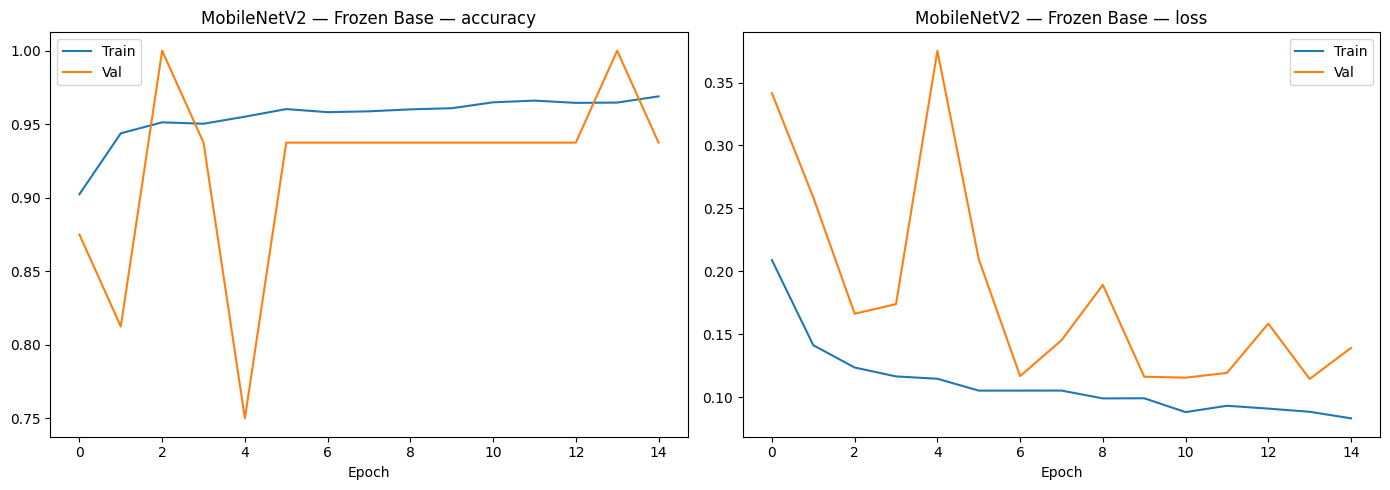

In [4]:
callbacks = get_callbacks(model_name='mobilenetv2_frozen', patience=5)

history_frozen = train_model(
    model, train_gen, val_gen,
    epochs=15,
    class_weights=class_weights,
    callbacks=callbacks,
)
plot_history(history_frozen, title='MobileNetV2 — Frozen Base')

## Step 2 — Fine-Tuning

Implement `unfreeze_top_layers()` in `src/models.py`, then continue training with a lower learning rate.

In [5]:
from src.models import unfreeze_top_layers

model = unfreeze_top_layers(model, num_layers=20)

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Trainable params after unfreezing: {trainable:,}')
print(f'Fine-tune learning rate: {model.optimizer.learning_rate.numpy():.2e}')

Trainable params after unfreezing: 2,552,577
Fine-tune learning rate: 1.00e-05


Epoch 1/10
163/163 [==============================] - 321s 2s/step - loss: 0.0921 - accuracy: 0.9651 - auc: 0.9933 - val_loss: 0.0284 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 2/10
163/163 [==============================] - 311s 2s/step - loss: 0.0847 - accuracy: 0.9655 - auc: 0.9948 - val_loss: 0.2153 - val_accuracy: 0.8750 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 3/10
163/163 [==============================] - 309s 2s/step - loss: 0.0828 - accuracy: 0.9666 - auc: 0.9950 - val_loss: 0.0621 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 1.0000e-05
Epoch 4/10
163/163 [==============================] - 312s 2s/step - loss: 0.0689 - accuracy: 0.9730 - auc: 0.9968 - val_loss: 0.0457 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 5.0000e-06
Epoch 5/10
163/163 [==============================] - 312s 2s/step - loss: 0.0598 - accuracy: 0.9791 - auc: 0.9972 - val_loss: 0.0139 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 5.0000e-06
Epoch 6/10
163/163 [====================

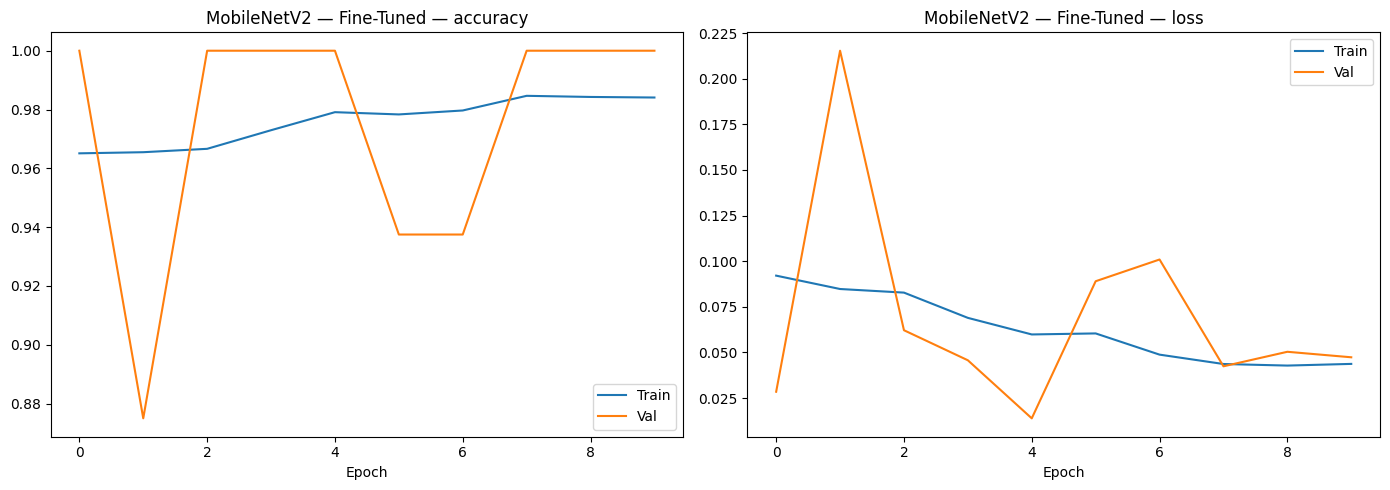

In [6]:
callbacks_ft = get_callbacks(model_name='mobilenetv2_finetune', patience=5)

history_ft = train_model(
    model, train_gen, val_gen,
    epochs=10,
    class_weights=class_weights,
    callbacks=callbacks_ft,
)
plot_history(history_ft, title='MobileNetV2 — Fine-Tuned')

## Step 3 — Compare All Three Base Models

Train VGG16, ResNet50, and MobileNetV2 and compare their test performance.

In [ ]:
from src.evaluate import evaluate_model, compare_models

comparison = {}
for base in ['MobileNetV2', 'VGG16', 'ResNet50']:
    print(f'\n--- Training {base} ---')
    m = build_transfer_model(base_model_name=base, input_shape=(224, 224, 3),
                              freeze_base=True, learning_rate=1e-3)
    cb = get_callbacks(model_name=base.lower(), patience=5)
    train_model(m, train_gen, val_gen, epochs=10, class_weights=class_weights, callbacks=cb)
    # TODO: implement evaluate_model() in src/evaluate.py
    comparison[base] = evaluate_model(m, test_gen)
    print(f"{base} test accuracy: {comparison[base]['accuracy']:.4f}")

compare_models(comparison)

## 4. Save Best Model

In [ ]:
# Save the best performing transfer learning model
best_base = max(comparison, key=lambda k: comparison[k]['accuracy'])
print(f'Best base model: {best_base}')
model.save(f'../models/{best_base.lower()}_best.keras')
print('Model saved.')

## 5. Reflection Questions

1. Why does feature extraction work even though the base was trained on natural images (ImageNet), not X-rays?
2. Which layers learn low-level vs high-level features? Why do we only fine-tune the top layers?
3. Why must the learning rate be much lower during fine-tuning than during feature extraction?
4. Compare your best transfer model against the Phase 1 MLP. Quantify the improvement.

**Your answers here:**

1. 
2. 
3. 
4. 